<a href="https://colab.research.google.com/github/Sharmaluvkesh/Ship-Performance-Comprehensive-Clustering-Workflow/blob/main/ship_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ship Performance Comprehensive Clustering Workflow
This notebook guides you through an end-to-end unsupervised clustering pipeline using the `Ship_Performance_Dataset.csv` dataset. It covers data preparation, K-Means Clustering (Elbow Method), and Hierarchical Clustering (Dendrogram Layout).

### Section 1: Library Imports & Loading Data
Bringing in all necessary tools for handling data, scaling features, plotting, and training both K-Means and Hierarchical Clustering models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [2]:
# Loads your ship performance dataset into a pandas dataframe
df = pd.read_csv('Ship_Performance_Dataset.csv')
df.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


### Section 2: Data Exploration & Structural Check
Checking the shape of the dataset, looking for missing values, column data types, and verifying column alignment.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   object 
 1   Ship_Type                2600 non-null   object 
 2   Route_Type               2600 non-null   object 
 3   Engine_Type              2600 non-null   object 
 4   Maintenance_Status       2600 non-null   object 
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   object 
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Efficiency_nm_per_kWh   

In [4]:
df.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


### Section 3: Exploratory Data Analysis (EDA) via Visualizations
Analyzing relationships between key operational numerical traits such as engine power, distance, and costs.

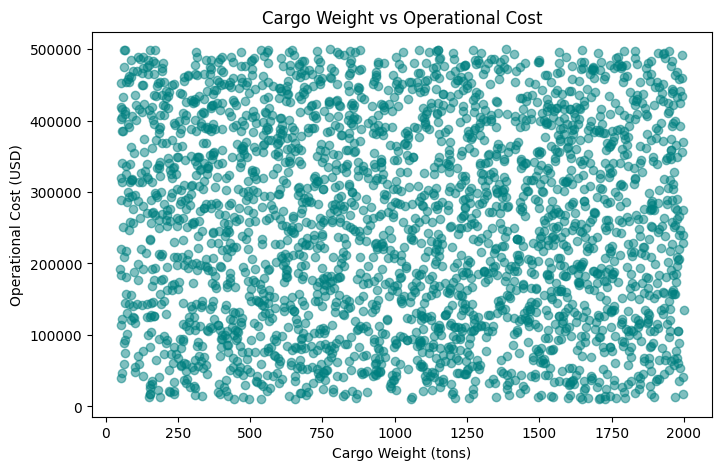

In [5]:
# Visualizing the relationship between Cargo Weight and Operational Cost
plt.figure(figsize=(8, 5))
plt.scatter(df['Cargo_Weight_tons'], df['Operational_Cost_USD'], alpha=0.5, color='teal')
plt.xlabel('Cargo Weight (tons)')
plt.ylabel('Operational Cost (USD)')
plt.title('Cargo Weight vs Operational Cost')
plt.show()

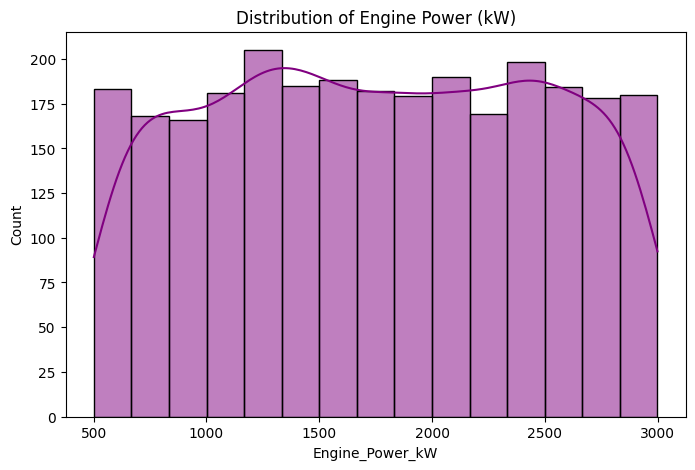

In [6]:
# Visualizing the distribution of Engine Power
plt.figure(figsize=(8, 5))
sns.histplot(df['Engine_Power_kW'], kde=True, color='purple')
plt.title('Distribution of Engine Power (kW)')
plt.show()

In [7]:
df.columns

Index(['Date', 'Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status',
       'Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm',
       'Draft_meters', 'Weather_Condition', 'Cargo_Weight_tons',
       'Operational_Cost_USD', 'Revenue_per_Voyage_USD',
       'Turnaround_Time_hours', 'Efficiency_nm_per_kWh',
       'Seasonal_Impact_Score', 'Weekly_Voyage_Count',
       'Average_Load_Percentage'],
      dtype='object')

### Section 4: Data Preprocessing & Feature Selection
Selecting numerical features suitable for distance-based clustering and applying feature scaling to standardize variance.

In [8]:
# Selecting only relevant continuous numeric features for clustering
numeric_cols = [
    'Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm',
    'Draft_meters', 'Cargo_Weight_tons', 'Operational_Cost_USD',
    'Revenue_per_Voyage_USD', 'Turnaround_Time_hours',
    'Efficiency_nm_per_kWh', 'Average_Load_Percentage'
]
x = df[numeric_cols]
x.head()

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Average_Load_Percentage
0,12.597558,2062.983982,1030.943616,14.132284,1959.017882,483832.354540,292183.273104,25.867077,1.455179,93.769249
1,10.387580,1796.057415,1060.486382,14.653083,162.394712,483388.000509,883765.787360,63.248196,0.290361,93.895372
2,20.749747,1648.556685,658.874144,7.199261,178.040917,448543.404044,394018.746904,49.418150,0.499595,96.218244
3,21.055102,915.261795,1126.822519,11.789063,1737.385346,261349.605449,87551.375175,22.409110,0.702906,66.193698
4,13.742777,1089.721803,1445.281159,9.727833,260.595103,287718.375160,676121.459632,64.158231,1.331343,80.008581


In [9]:
# Standardizing features using StandardScaler so all features contribute equally to distances
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print('Scaled feature matrix shape:', x_scaled.shape)

Scaled feature matrix shape: (2736, 10)


### Section 5: Finding the Optimal Number of Clusters (Elbow Method)
Calculating the Within-Cluster Sum of Squares (WCSS) across varying cluster numbers to locate the 'elbow point'.

In [10]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

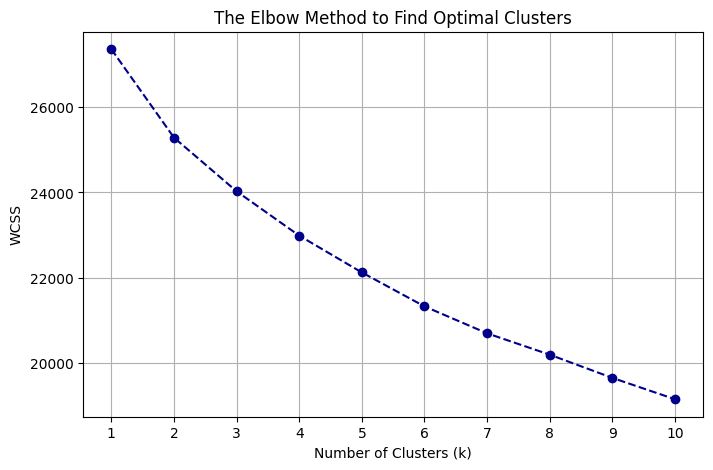

In [11]:
# Plotting the Elbow Curve graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')
plt.title('The Elbow Method to Find Optimal Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Section 6: Training K-Means Model
Initializing K-Means with the chosen optimal number of clusters (e.g., 3 clusters) and fitting it on the dataset.

In [12]:
# Select optimal number of clusters based on the elbow plot above
optimal_k = 3
model_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

In [13]:
# Fitting model and predicting the corresponding cluster assignments
kmeans_clusters = model_kmeans.fit_predict(x_scaled)
df['KMeans_Cluster'] = kmeans_clusters
df.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage,KMeans_Cluster
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249,1
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372,0
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244,0
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698,2
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581,1


### Section 7: Visualizing Generated K-Means Clusters
Plotting scatter graphs colored by cluster labels to clearly see distinct operational groupings.

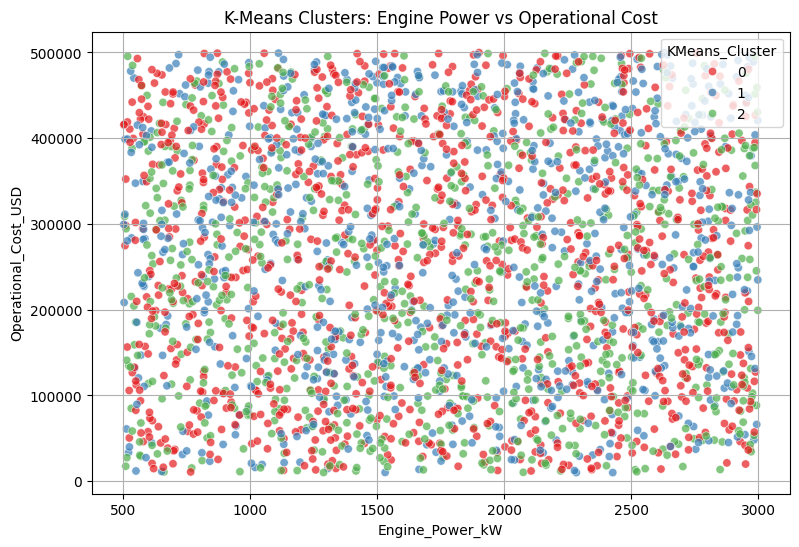

In [14]:
# Visualizing Clusters: Engine Power vs Operational Cost
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Engine_Power_kW', y='Operational_Cost_USD', hue='KMeans_Cluster', palette='Set1', alpha=0.7)
plt.title('K-Means Clusters: Engine Power vs Operational Cost')
plt.grid(True)
plt.show()

### Section 8: Hierarchical Clustering Layout & Dendrogram
Computing hierarchical links using Ward's linkage method and plotting a truncated dendrogram layout for finding structural groupings.

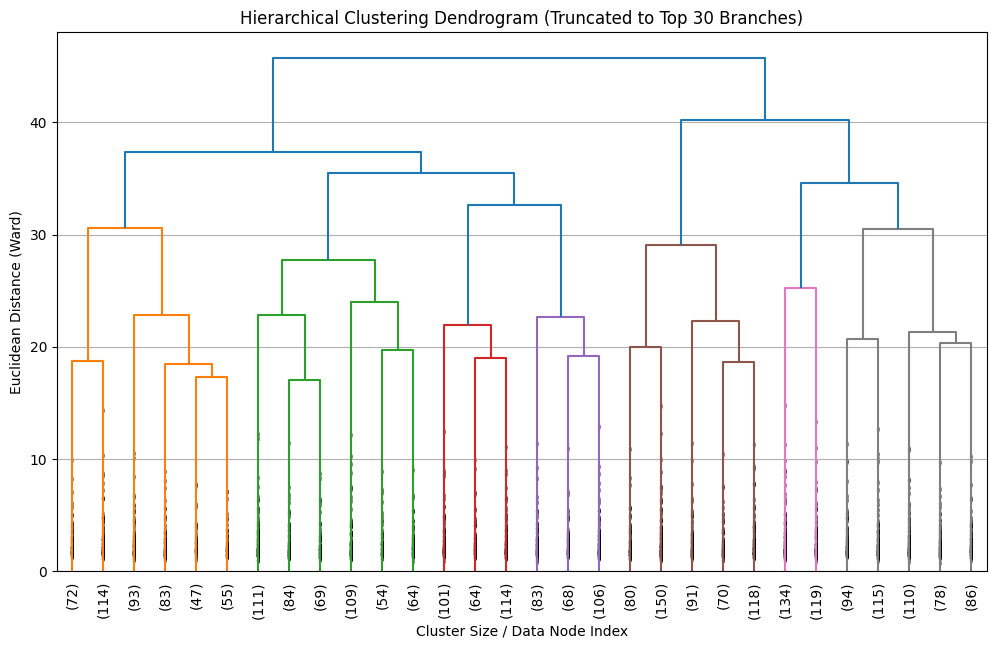

In [15]:
plt.figure(figsize=(12, 7))

# Compute the linkage matrix using Ward's minimum variance method
linkage_matrix = sch.linkage(x_scaled, method='ward')

# Plot the dendrogram (truncated to show the top 30 merged branches for neatness)
dendrogram = sch.dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Hierarchical Clustering Dendrogram (Truncated to Top 30 Branches)')
plt.xlabel('Cluster Size / Data Node Index')
plt.ylabel('Euclidean Distance (Ward)')
plt.grid(axis='y')
plt.show()

### Section 9: Training Agglomerative Hierarchical Clustering Model
Applying the cluster counts determined from the dendrogram splits above to generate a separate set of tree labels.

In [16]:
# Running hierarchical grouping using Agglomerative Clustering
model_hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_clusters = model_hc.fit_predict(x_scaled)

df['HC_Cluster'] = hc_clusters
df.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage,KMeans_Cluster,HC_Cluster
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249,1,0
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372,0,0
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244,0,0
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698,2,2
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581,1,1


### Section 10: Visualizing Generated Hierarchical Clusters
Plotting scatter graphs colored by your hierarchical labels to see how well the tree structure worked.

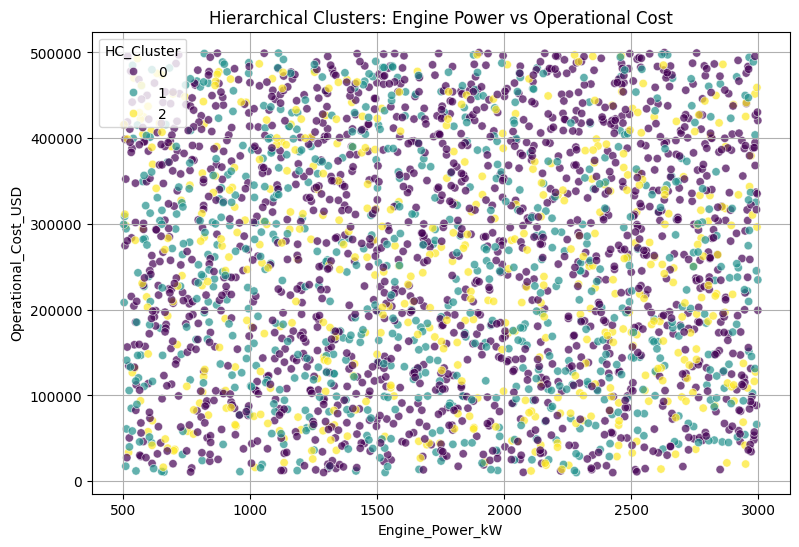

In [17]:
# Visualizing Hierarchical Clusters: Engine Power vs Operational Cost
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Engine_Power_kW', y='Operational_Cost_USD', hue='HC_Cluster', palette='viridis', alpha=0.7)
plt.title('Hierarchical Clusters: Engine Power vs Operational Cost')
plt.grid(True)
plt.show()

### Section 11: Cluster Profiling & Comparison
Grouping the dataframe to look at the statistical summary profile differences between your clusters.

In [18]:
# Displaying the statistical profiles of K-Means groupings
print('--- K-Means Cluster Averages ---')
df.groupby('KMeans_Cluster')[numeric_cols].mean()

--- K-Means Cluster Averages ---


,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Average_Load_Percentage
KMeans_Cluster,,,,,,,,,,
0,17.334082,1726.854116,1099.199788,10.067442,1004.029183,252630.466883,542637.896053,41.544329,0.393555,76.363315
1,17.614471,1796.692280,1097.622707,10.029423,1124.698682,276102.267865,745886.332363,36.036404,1.089500,74.292080
2,17.920825,1757.996434,901.164404,9.664094,979.670236,238234.281656,281223.670562,47.442099,1.017230,74.702740


In [19]:
# Displaying the statistical profiles of Hierarchical groupings
print('--- Hierarchical (HC) Cluster Averages ---')
df.groupby('HC_Cluster')[numeric_cols].mean()

--- Hierarchical (HC) Cluster Averages ---


,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Average_Load_Percentage
HC_Cluster,,,,,,,,,,
0,16.838065,1773.743212,928.796432,9.580292,1033.676052,263859.879084,444520.691503,45.033174,0.719950,79.322150
1,19.129658,1702.111948,1038.532137,10.254093,1080.752265,244066.416140,640963.047048,39.927021,1.103856,74.122714
2,17.635463,1790.605121,1348.550565,10.480938,959.677388,245627.168024,573511.685667,34.755419,0.587892,64.786145
